# Project 1 — Linear Regression
## House Price Prediction

Predicting house sale price from area (sqft), number of bedrooms, house age, and a location desirability score.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
np.random.seed(42)
pd.set_option('display.max_columns', None)


## 1. Generate / Load Data

In [2]:
n = 800
area = np.random.normal(1800, 500, n).clip(500, 5000)
bedrooms = np.random.randint(1, 6, n)
age = np.random.randint(0, 60, n)
location_score = np.random.uniform(1, 10, n)

price = (30000 + 120*area + 8000*bedrooms - 400*age + 15000*location_score
          + np.random.normal(0, 20000, n))

df = pd.DataFrame({'area': area, 'bedrooms': bedrooms, 'age': age,
                    'location_score': location_score, 'price': price})
df.head()


,area,bedrooms,age,location_score,price
0,2048.357077,2,20,4.516555,365094.372780
1,1730.867849,3,1,8.185098,376773.347525
2,2123.844269,2,26,4.347394,337605.352729
3,2561.514928,1,56,5.065271,397176.352922
4,1682.923313,3,8,4.576433,339385.986047


## 2. Preprocessing

In [3]:
X = df.drop('price', axis=1)
y = df['price']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


## 3. Train Model

In [4]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train_scaled, y_train)
y_pred = model.predict(X_test_scaled)


## 4. Evaluate

In [5]:
print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R2 Score:", r2_score(y_test, y_pred))


MAE: 16332.639455164433
RMSE: 20116.752272267764
R2 Score: 0.9200867232051047


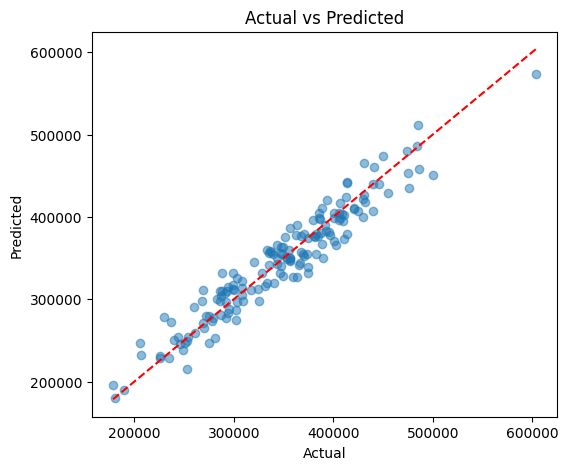

In [6]:
plt.figure(figsize=(6,5))
plt.scatter(y_test, y_pred, alpha=0.5)
lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
plt.plot(lims, lims, 'r--')
plt.xlabel('Actual'); plt.ylabel('Predicted'); plt.title('Actual vs Predicted')
plt.show()


## Takeaways
- Coefficients (`model.coef_`) show the effect of each standardized feature on price — area and location_score should dominate.
- Check residual plots (`y_test - y_pred` vs `y_pred`) for patterns that would indicate a non-linear relationship being missed.
- Next steps: try adding polynomial features (e.g., area²) if residuals show curvature.

---
